# Import Libraries:

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# Loading the Dataset

In [20]:
dataset = pd.read_csv(r"C:\Users\sangm\Downloads\sales_data_with_discounts.csv")

In [48]:
dataset.head(3)

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843


In [49]:
dataset.shape

(450, 13)

In [22]:
dataset.isnull().sum()

Date                 0
Day                  0
SKU                  0
City                 0
Volume               0
BU                   0
Brand                0
Model                0
Avg Price            0
Total Sales Value    0
Discount Rate (%)    0
Discount Amount      0
Net Sales Value      0
dtype: int64

In [23]:
dataset.dtypes

Date                  object
Day                   object
SKU                   object
City                  object
Volume                 int64
BU                    object
Brand                 object
Model                 object
Avg Price              int64
Total Sales Value      int64
Discount Rate (%)    float64
Discount Amount      float64
Net Sales Value      float64
dtype: object

# Identifying numerical columns in the dataset

In [24]:
numerical_cols = dataset.select_dtypes(include=['number']).columns.tolist()

In [25]:
numerical_cols

['Volume',
 'Avg Price',
 'Total Sales Value',
 'Discount Rate (%)',
 'Discount Amount',
 'Net Sales Value']

## Identifying numerical columns in the dataset

In [53]:
object_cols = dataset.select_dtypes(include=['object']).columns.tolist()

In [78]:
object_cols

['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model']

# The mean, median, mode, and standard deviation for these columns.

In [28]:
dataset.describe()

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,5.066667,10453.433333,33812.835556,15.155242,3346.499424,30466.336131
std,4.231602,18079.904840,50535.074173,4.220602,4509.902963,46358.656624
min,1.000000,290.000000,400.000000,5.007822,69.177942,326.974801
25%,3.000000,465.000000,2700.000000,13.965063,460.459304,2202.208645
50%,4.000000,1450.000000,5700.000000,16.577766,988.933733,4677.788059
75%,6.000000,10100.000000,53200.000000,18.114718,5316.495427,47847.912852
max,31.000000,60100.000000,196400.000000,19.992407,25738.022194,179507.479049


# Data Visualization

## Histogram

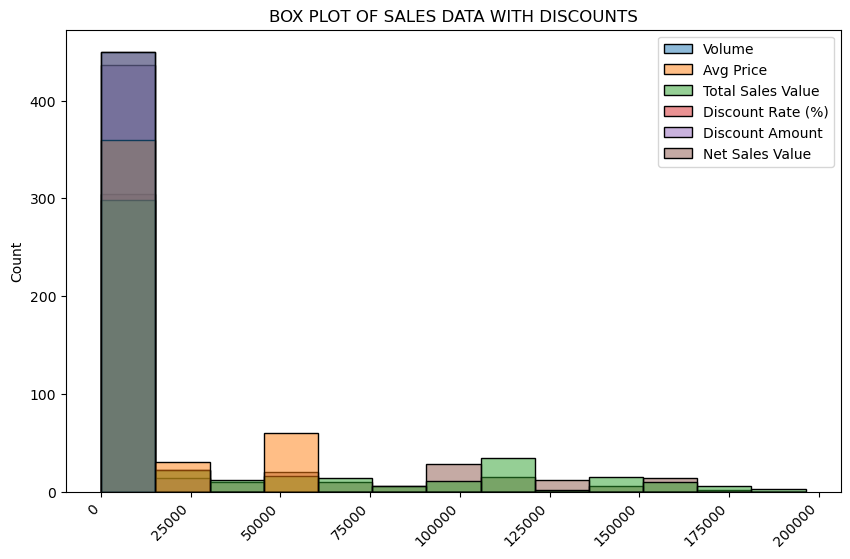

In [50]:
plt.figure(figsize=(10, 6))
sns.histplot(data=dataset,bins=13,kde=False)
plt.title('BOX PLOT OF SALES DATA WITH DISCOUNTS')
plt.xticks(rotation=45, ha='right')
plt.show()

## Boxplot

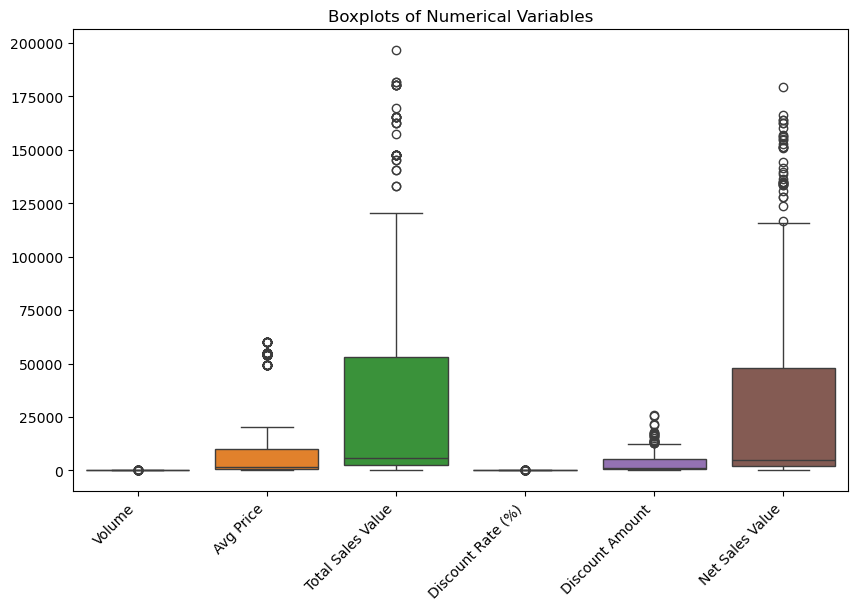

In [30]:
data_for_boxplots = dataset[numerical_cols]
plt.figure(figsize=(10, 6))
sns.boxplot(data=data_for_boxplots)
plt.title('Boxplots of Numerical Variables')
plt.xticks(rotation=45, ha='right')
plt.show()

## Bar Chart 

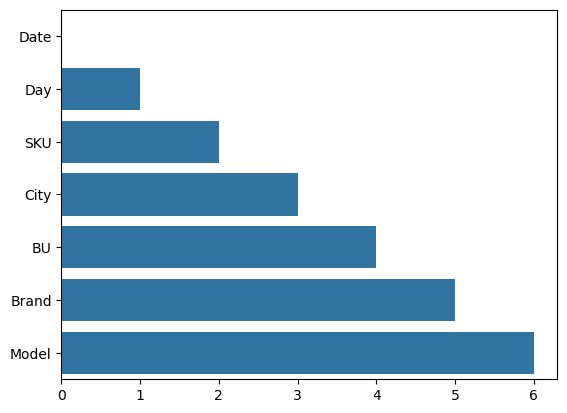

<Figure size 800x600 with 0 Axes>

In [47]:
sns.barplot(data=object_cols) #x and y column is not defined in question so not assming on which bases we have to compare it with. 
plt.figure(figsize=(8, 6))
plt.show()

# Standardization of Numerical Variables

In [52]:
scaling = StandardScaler()

In [65]:
dataset_scaled = scaling.fit_transform(dataset[['Volume','Avg Price','Total Sales Value','Discount Rate (%)','Discount Amount','Net Sales Value']])
dataset_scaled

array([[ 2.35002911,  0.091173  ,  2.92572115, -0.83028851,  3.95281631,
         2.80475594],
       [ 1.16712855, -0.01957016,  1.33099521, -0.85266145,  1.84901409,
         1.2710262 ],
       [ 0.45738822,  0.31265934,  1.56277525, -1.35163138,  1.62299458,
         1.54567497],
       ...,
       [-0.72551234, -0.49022863, -0.60644824,  0.90379261, -0.60813967,
        -0.60192115],
       [-0.48893223, -0.47361715, -0.55692259,  0.38847428, -0.53037877,
        -0.55549857],
       [-0.96209245, -0.40717125, -0.60842926,  0.04223476, -0.63734468,
        -0.60123949]])

Concept of Standardization (Z-score Normalization):

Ans => Standardization, also known as z-score normalization, is a data preprocessing technique that transforms the features of a dataset so that they have a mean of 0 and a standard deviation of 1. This is done by centering the data (subtracting the mean) and scaling it (dividing by the standard deviation), making it easier to compare features with different scales and units.

z = (x - μ) / σ

Where:=>
z => is the standardized value (z-score)
x => is the original data point
μ => is the mean of the feature
σ => is the standard deviation of the feature

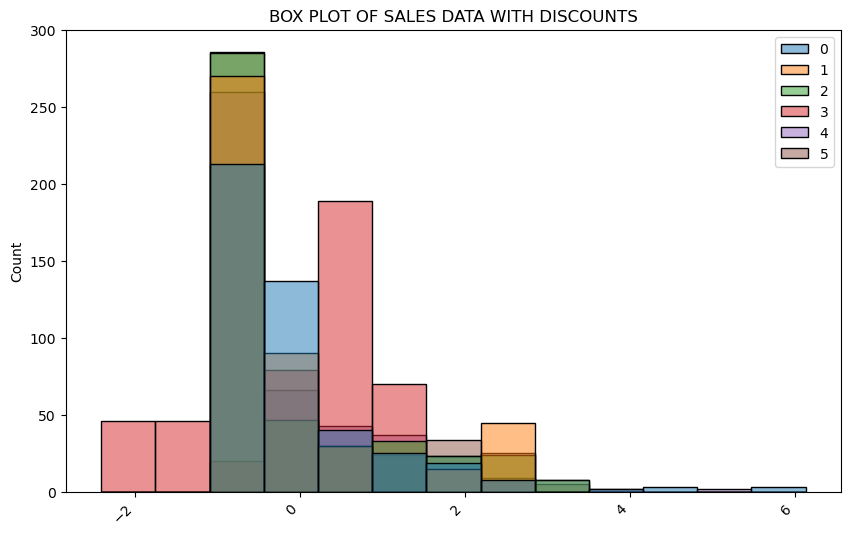

In [66]:
plt.figure(figsize=(10, 6))
sns.histplot(data=dataset_scaled,bins=13,kde=False)
plt.title('BOX PLOT OF SALES DATA WITH DISCOUNTS')
plt.xticks(rotation=45, ha='right')
plt.show()

First Image:Of Boxplot

Appears to be a stacked histogram or bar plot representing different categories.
The x-axis seems to display discount categories or rates (0 to 6).
The legend on the right side has numbers (0, 1, 2, etc.), suggesting different discount types or categories.
There’s a high frequency for the category around 0 on the x-axis, indicating that most data points fall within a particular discount level.

Second Image:Of Boxplot

Also a stacked bar plot but with a larger range on the x-axis, likely showing different sales values or total values in thousands.
The legend categories are labeled as "Volume," "Avg Price," "Total Sales Value," "Discount Rate (%)", "Discount Amount," and "Net Sales Value."
It shows a concentration of values near the lower range, which might represent low total sales values or net sales values, with some outliers or fewer entries at higher values (up to 1,000,000).

Key Differences:

X-axis Scaling: The first image uses smaller integers (probably for discount categories), while the second image represents much larger values (likely monetary).

Legend Categories: The first image uses numbered categories, which are likely codes for specific discount levels. The second image uses descriptive labels related to sales metrics, providing more context on each category.

Distribution: Both images show a high count at lower values, but the first image's categories appear more evenly distributed, whereas the second has a significant concentration at the lowest value (possibly indicating more frequent, lower-value sales transactions).

# Conversion of Categorical Data into Dummy Variables

Converting categorical data into dummy variables, also known as one-hot encoding, is an essential preprocessing step in many machine learning models. Categorical data often contains non-numeric values that represent categories, such as "red," "blue," "green" (for colors) or "dog," "cat," "bird" (for animal types). Since many algorithms expect numeric input, these categorical values need to be converted into a numerical format without introducing unintended relationships. The three main reasons are =>

1 =>Compatibility with Machine Learning Algorithms: Most algorithms, such as linear regression, decision trees, and neural networks, cannot handle categorical data directly. They expect numerical inputs to compute mathematical operations like distances or gradients. Dummy variables provide a way to convert categories into a format these algorithms can process.

2 => Avoiding Ordinal Relationships: Simply assigning integer values to categories (e.g., "red" = 1, "blue" = 2, "green" = 3) implies an ordinal relationship (e.g., green > blue > red), which may not exist. One-hot encoding avoids this issue by creating separate binary (0 or 1) columns for each category, ensuring that no unintended hierarchy or order is implied.

3 => Improving Model Interpretability: Dummy variables provide a clear, interpretable representation of each category, making it easier to understand which categories influence the model’s predictions. For instance, in a one-hot encoded "Color" variable, the columns "Color_red," "Color_blue," and "Color_green" explicitly represent each color's presence or absence.

In [77]:
oh_enc = OneHotEncoder(sparse_output=False)

In [83]:
oh_enc_arr = oh_enc.fit_transform(dataset[['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model']])
oh_enc_arr

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

# Conclusion

1. Histograms:
Skewness: Histograms revealed the skewness of numerical variables like 'Sales', 'Discount', etc. Positive skew (right-skewed) suggests that most sales or discounts fall within a lower range with a few high-value outliers. Negative skew (left-skewed) would indicate the opposite.
Outliers: Histograms, often combined with IQR analysis, helped identify potential outliers in numerical columns. Outliers are data points that significantly deviate from the typical range and can influence statistical calculations.
Distribution Shapes: Histograms provided insights into the shapes of distributions, such as normal, uniform, or bimodal, offering valuable information about the underlying data patterns.

2. Boxplots:
Outliers: Boxplots visually displayed outliers as points outside the whiskers. This allowed for easy identification of extreme values in numerical data.
Interquartile Range (IQR): The box in the boxplot represents the IQR, indicating the range where the central 50% of the data lies. This is useful for understanding data spread and variability.
Unusual Distributions: Boxplots can reveal unusual distributions, such as those with heavy tails or multiple clusters, suggesting potential data segmentation or subgroups.

3. Bar Charts:
Category Frequencies: Bar charts were used to visualize the frequency or count of each category in categorical columns like 'Product Category' or 'Customer Segment'. This revealed the popularity or prevalence of different categories.
Category Distribution: The bar charts provided insights into the overall distribution of categories, identifying the most and least frequent ones. This information can be valuable for understanding customer preferences or sales trends for specific categories.
Business Insights: Analyzing category distributions can lead to insights into customer segmentation, product demand, and potential areas for targeted marketing or inventory management.

Data preprocessing is a crucial step in data analysis and machine learning because it directly affects model performance, interpretability, and reliability. Techniques like standardization and one-hot encoding help transform raw data into a format that machine learning algorithms can effectively learn from, leading to more accurate, efficient, and understandable models. Here’s a reflection on the importance of these and other data preprocessing steps:

1. Ensuring Consistent Data Scaling: Standardization
Standardization (z-score normalization) is essential for algorithms that rely on distance calculations or gradient-based optimization, such as k-nearest neighbors (KNN), support vector machines (SVM), and neural networks.
Without standardization, features with larger scales (e.g., income in thousands vs. age in years) could dominate the model, leading to biased predictions.
Standardized data also helps achieve faster convergence during training for algorithms like gradient descent, improving computational efficiency.
By bringing all features to a common scale, standardization ensures that each feature contributes equally to the model, which is essential for fair and balanced learning.

2. Encoding Categorical Data: One-Hot Encoding
One-hot encoding transforms categorical features into binary columns, allowing machine learning algorithms to interpret and utilize categorical information effectively.
This encoding prevents unintended ordinal relationships between categories, ensuring that "Color_blue" and "Color_red" are seen as separate entities rather than numbers with a hierarchy.
For interpretability, one-hot encoded variables make it clear which categories affect the model's predictions, facilitating analysis and feature importance evaluation.
However, this step must be handled with care when there are high-cardinality categorical variables (categories with many unique values), as it can significantly increase the dataset's dimensionality, potentially leading to overfitting.

3. Handling Missing Values
Imputing or managing missing values is essential, as missing data can cause errors during model training or lead to biased results.
Appropriate handling of missing values—such as mean/mode imputation or using algorithms that handle missingness internally—helps preserve data integrity and ensures that the model can make consistent predictions.